In [61]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
data_dir = Path("virat_kohli_data")
dataframes = []

In [63]:
for file in data_dir.glob("*.csv"):
    df = pd.read_csv(file)
    dataframes.append(df)

In [64]:
kohli_tests = pd.concat(dataframes, ignore_index=True)
kohli_tests = kohli_tests[kohli_tests["striker"] == "V Kohli"].sort_values("start_date")

In [65]:
kohli_tests.head(1)

,match_id,season,start_date,venue,innings,ball,actual_delivery,batting_team,bowling_team,striker,...,legbyes,penalty,non_boundary,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,fielder_1,fielder_2,fielder_3
26657,489226,2011,2011-06-20,"Sabina Park, Kingston",1,22.2,22.2,India,West Indies,V Kohli,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
# early_kohli = kohli_tests[(kohli_tests["start_date"].str[:4] == "2011") | (kohli_tests["start_date"].str[:4] == "2012") | (kohli_tests["start_date"].str[:4] == "2013") | (kohli_tests["start_date"].str[:4] == "2014")
#             | (kohli_tests["start_date"].str[:4] == "2015")]

years = []
avg = []
for i in range(2011, 2026):
    years.append(i)
    avg.append((kohli_tests[kohli_tests["start_date"].str[:4] == str(i)]["runs_off_bat"].sum()) / (kohli_tests[kohli_tests["start_date"].str[:4] == str(i)]["player_dismissed"].eq("V Kohli").sum()))

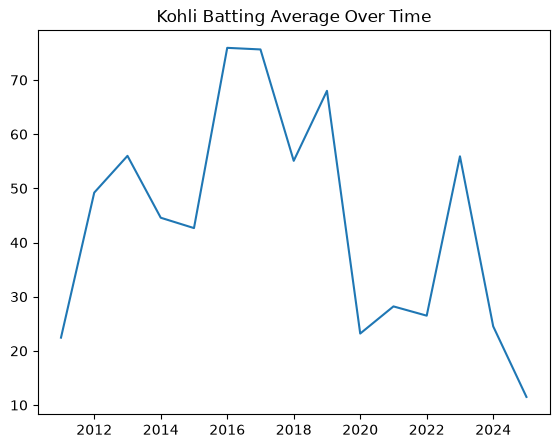

In [67]:
fig = plt.figure()
axes1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])
axes1.set_title("Kohli Batting Average Over Time")
axes1.plot(years, avg)
plt.show()

In [68]:
kohli_test_dismissals = kohli_tests.dropna(subset=["wicket_type"])

In [69]:
early_kohli_test_dismissals = kohli_test_dismissals[
    kohli_test_dismissals["start_date"].str[:4].astype(int).between(2011, 2015)
]

In [70]:
early_kohli_test_dismissals = early_kohli_test_dismissals.sort_values("start_date")

In [71]:
middle_kohli_test_dismissals = kohli_test_dismissals[
    kohli_test_dismissals["start_date"].str[:4].astype(int).between(2016, 2019)
]

In [72]:
middle_kohli_test_dismissals = middle_kohli_test_dismissals.sort_values("start_date")

In [73]:
middle_kohli_test_dismissals["wicket_type"].value_counts()

wicket_type
caught               42
lbw                  16
bowled                3
hit wicket            1
run out               1
caught and bowled     1
Name: count, dtype: int64

In [ ]:
sns.countplot(
    data=
)